# Linear Regression for Stellar Luminosity 

### Configuración inicial

In [1]:
%pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D




### Dataset

In [3]:
#  (M⊙) y (L⊙)
M = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
L = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])
n = len(M)


### Visualización del dataset

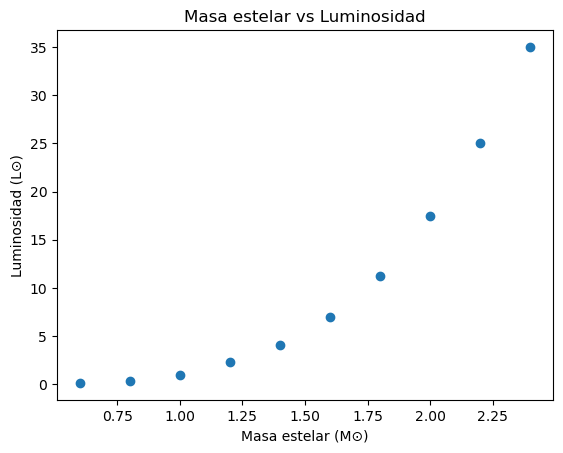

In [4]:
plt.figure()
plt.scatter(M, L)
plt.xlabel("Masa estelar (M⊙)")
plt.ylabel("Luminosidad (L⊙)")
plt.title("Masa estelar vs Luminosidad")
plt.show()


#### Linealidad y pausabilidad


Tiene todo el sentido del mundo que las estrellas más masivas sean también más luminosas, y eso lo vemos claramente en los datos: a medida que la masa aumenta, la luminosidad también lo hace. Por eso, probar un modelo lineal es una buena forma de empezar.

Sin embargo, la relación no es totalmente lineal. La luminosidad aumenta cada vez más rápido a medida que la masa crece, algo que coincide con lo que sabemos en astronomía, donde la luminosidad suele seguir una relación de potencia con la masa. Por eso, aunque el modelo lineal nos da una idea general, no captura todos los detalles del comportamiento real.


Se utiliza un modelo lineal:

L̂ = wM + b

donde:
- w representa la pendiente del modelo
- b es el término de sesgo o intercepto


### Modelo y función de pérdida

In [5]:
def predict(M, w, b):
    return w * M + b

def mse_loss(M, L, w, b):
    L_hat = predict(M, w, b)
    return np.mean((L_hat - L) ** 2)


### Evaluación del costo

In [6]:
w_vals = np.linspace(-20, 30, 100)
b_vals = np.linspace(-20, 20, 100)

W, B = np.meshgrid(w_vals, b_vals)
J = np.zeros((len(w_vals), len(b_vals)))

for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        J[i, j] = mse_loss(M, L, W[i, j], B[i, j])


### Gráfica de contornos del costo

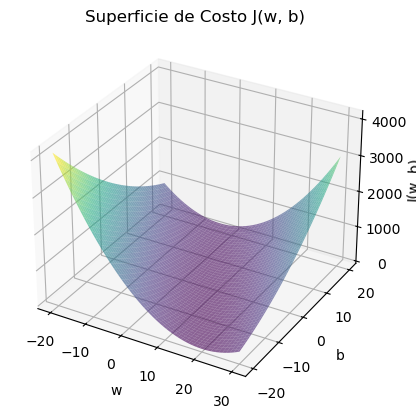

In [7]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(W, B, J, alpha=0.6, cmap='viridis')

ax.set_xlabel("w")
ax.set_ylabel("b")
ax.set_zlabel("J(w, b)")
ax.set_title("Superficie de Costo J(w, b)")

plt.show()



##### Interpretación

El mínimo de la superficie de costo representa los valores óptimos de
w y b que minimizan el error cuadrático medio. El algoritmo de descenso
por gradiente busca iterativamente este punto.


## Gradientes

Las derivadas parciales del error cuadrático medio son:

∂J/∂w = (2/n) Σ (wMᵢ + b − Lᵢ) Mᵢ  
∂J/∂b = (2/n) Σ (wMᵢ + b − Lᵢ)


### Gradientes NO vectorizados

In [8]:
def gradientes_no_vectorizados(M, L, w, b):
    
    n = len(M)
    dw = 0.0
    db = 0.0
    
    for i in range(n):
        L_hat_i = w * M[i] + b
        error_i = L_hat_i - L[i]
        
        dw += error_i * M[i]
        db += error_i
    
    dw = (2 / n) * dw
    db = (2 / n) * db
    
    return dw, db


### Gradientes vectorizados

In [9]:
def gradientes_vectorizados(M, L, w, b):
    n = M.shape[0]
    
    L_hat = w * M + b          
    error = L_hat - L          
    
    dw = (2 / n) * np.dot(error, M)
    db = (2 / n) * np.sum(error)
    
    return dw, db


#### Pequeña verificacion



In [10]:
w_test, b_test = 3.0, 1.5

dw_loop, db_loop = gradientes_no_vectorizados(M, L, w_test, b_test)
dw_vec, db_vec = gradientes_vectorizados(M, L, w_test, b_test)

print("dw difference:", abs(dw_loop - dw_vec))
print("db difference:", abs(db_loop - db_vec))


dw difference: 3.552713678800501e-15
db difference: 0.0


Las diferencias son cero, lo que confirma que ambas implementaciones calculan los mismos gradientes :).

## ENTRENAMIENTO Y CONVERGENCIA

### Descenso por gradiente

In [11]:
def descenso_gradiente(M, L, lr, iterations):
    w, b = 0.0, 0.0
    loss_history = []
    
    for _ in range(iterations):
        dw, db = gradientes_vectorizados(M, L, w, b)
        w -= lr * dw
        b -= lr * db
        loss_history.append(mse_loss(M, L, w, b))
    
    return w, b, loss_history



### Tasas de aprendizaje diferentes

In [12]:
learning_rates = [0.001, 0.01, 0.05]
iterations = 2000

results = {}

for lr in learning_rates:
    w, b, loss_history = descenso_gradiente(M, L, lr, iterations)
    results[lr] = (w, b, loss_history)
    
    print(f"LR={lr} → w={w:.3f}, b={b:.3f}, final loss={loss_history[-1]:.3f}")

LR=0.001 → w=9.716, b=-2.894, final loss=44.696
LR=0.01 → w=17.853, b=-16.376, final loss=19.618
LR=0.05 → w=18.130, b=-16.835, final loss=19.590


### Convergencia

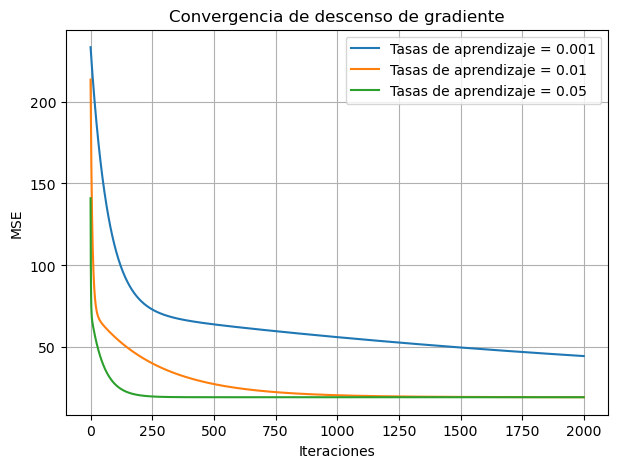

In [13]:
plt.figure(figsize=(7, 5))

for lr in learning_rates:
    loss_history = results[lr][2]
    plt.plot(loss_history, label=f"Tasas de aprendizaje = {lr}")

plt.xlabel("Iteraciones")
plt.ylabel("MSE")
plt.title("Convergencia de descenso de gradiente")
plt.legend()
plt.grid(True)
plt.show()


#### Convergencia

La pérdida disminuye de forma estable, lo que indica una convergencia
adecuada. Un valor de alpha demasiado grande puede causar divergencia,
mientras que uno muy pequeño ralentiza el aprendizaje.


### Ajuste Final

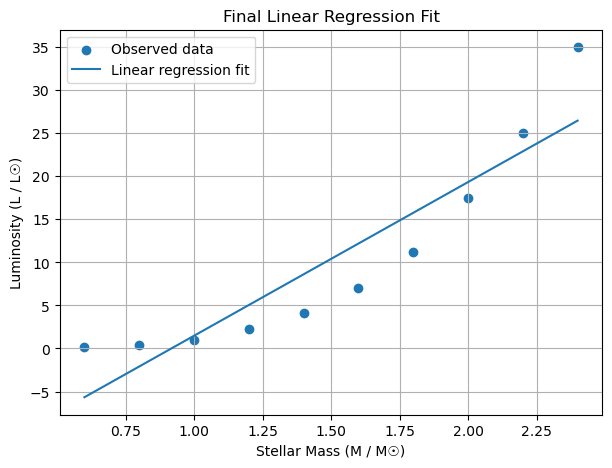

In [14]:
best_lr = 0.01
w_opt, b_opt, _ = results[best_lr]

M_line = np.linspace(M.min(), M.max(), 100)
L_pred_line = predict(M_line, w_opt, b_opt)

plt.figure(figsize=(7, 5))
plt.scatter(M, L, label="Observed data")
plt.plot(M_line, L_pred_line, label="Linear regression fit")
plt.xlabel("Stellar Mass (M / M☉)")
plt.ylabel("Luminosity (L / L☉)")
plt.title("Final Linear Regression Fit")
plt.legend()
plt.grid(True)
plt.show()


## Preguntas

1. Significado astrofísico de w

El parámetro w indica cuánto aumenta la luminosidad de una estrella cuando su masa crece. Es una forma de describir la relación entre masa y luminosidad.

2. ¿Por qué un modelo lineal es limitado?

Porque la luminosidad no aumenta de forma lineal con la masa. En los datos se observa que la luminosidad crece mucho más rápido, por lo que un modelo lineal no logra ajustarse bien, especialmente para estrellas más masivas.